# SA.2 – Análisis Supervisado: Clasificación
## Dataset: `diabetes.csv`
## Alumno: Santiago González Aguirre
## Fecha: 2026-08-19
---

## 1. Justificación del Algoritmo

Se seleccionó **Gradient Boosting Classifier** por las siguientes razones:

- El dataset de diabetes tiene **8 variables predictoras y 1 variable objetivo binaria** (0=No diabético, 1=Diabético). Gradient Boosting maneja bien esta dimensionalidad.
- El dataset presenta **clases desbalanceadas** (~65% negativos, ~35% positivos). Gradient Boosting puede ajustarse con métricas ponderadas y es menos sensible al desbalance que, por ejemplo, Regresión Logística.
- La relación entre variables como glucosa, BMI e insulina con la diabetes **no es lineal**, y Gradient Boosting captura interacciones complejas entre variables.
- **Alto rendimiento en benchmarks** de datasets biomédicos similares al Pima Indians Diabetes Dataset.
- **Interpretabilidad parcial** mediante la importancia de variables basada en reducción de impureza.

**Alternativas descartadas:** Random Forest (buena alternativa pero menos preciso en este tipo de datos tabulares pequeños), SVM (difícil interpretación y ajuste), Árbol de Decisión simple (propenso al sobreajuste sin poda).

## 2. Paso 1 – Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             roc_curve, f1_score, accuracy_score, precision_score, recall_score)
from sklearn.preprocessing import StandardScaler
import joblib

# Estilo visual
plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor': '#161b22',
    'axes.edgecolor': '#21262d',
    'axes.labelcolor': '#c9d1d9',
    'xtick.color': '#c9d1d9',
    'ytick.color': '#c9d1d9',
    'text.color': '#c9d1d9',
    'grid.color': '#21262d',
    'grid.alpha': 0.5,
})

C_POS = '#238636'   # verde - diabético positivo
C_NEG = '#da3633'   # rojo  - negativo
C_ACC = '#1f6feb'   # azul  - acento
C_WARN= '#e3b341'   # amarillo

print('Librerías cargadas ✓')

Librerías cargadas ✓


## 3. Paso 2 – Carga y exploración del dataset

In [2]:
df = pd.read_csv('diabetes.csv')

print(f'Shape: {df.shape}')
print(f'Columnas: {list(df.columns)}')
print(f'\nDistribución de clase objetivo:')
print(df['Outcome'].value_counts())
print(f'\n% Diabéticos: {df["Outcome"].mean()*100:.1f}%')
df.head()

Shape: (768, 9)
Columnas: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Distribución de clase objetivo:
Outcome
0    500
1    268
Name: count, dtype: int64

% Diabéticos: 34.9%


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
print('Estadísticas descriptivas:')
df.describe()

Estadísticas descriptivas:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## 4. Paso 3 – Preprocesamiento

In [7]:
# Columnas con ceros que representan valores faltantes médicamente imposibles
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print('Ceros (valores faltantes implícitos) antes de imputación:')
for col in cols_with_zeros:
    zeros = (df[col] == 0).sum()
    print(f'  {col}: {zeros} ceros ({zeros/len(df)*100:.1f}%)')

# Reemplazar ceros con la mediana por clase (imputación estratificada)
df_clean = df.copy()
for col in cols_with_zeros:
    df_clean[col] = df_clean[col].replace(0, np.nan)
    medians = df_clean.groupby('Outcome')[col].transform('median')
    df_clean[col] = df_clean[col].fillna(medians)
    # Safety net: si aún quedan NaN (grupo completo era 0), usar mediana global
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Verificación final
print('\nNaN tras imputación por columna:')
print(df_clean.isnull().sum())
print(f'\nTotal NaN: {df_clean.isnull().sum().sum()}  ← debe ser 0')

print('\nCeros después de imputación:')
for col in cols_with_zeros:
    zeros = (df_clean[col] == 0).sum()
    print(f'  {col}: {zeros}')

print('\n✓ Imputación completada')

Ceros (valores faltantes implícitos) antes de imputación:
  Glucose: 5 ceros (0.7%)
  BloodPressure: 35 ceros (4.6%)
  SkinThickness: 227 ceros (29.6%)
  Insulin: 374 ceros (48.7%)
  BMI: 11 ceros (1.4%)

NaN tras imputación por columna:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Total NaN: 0  ← debe ser 0

Ceros después de imputación:
  Glucose: 0
  BloodPressure: 0
  SkinThickness: 0
  Insulin: 0
  BMI: 0

✓ Imputación completada


## 5. Paso 4 – Entrenamiento modelo base

In [9]:
# Separación features / target
X = df_clean.drop(columns=['Outcome'])
y = df_clean['Outcome']

# Verificar que no queden NaN antes de escalar
assert X.isnull().sum().sum() == 0, f"Aún hay NaN: {X.isnull().sum()}"

# Escalar
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Verificar que no queden NaN ni inf después de escalar
assert np.isfinite(X_scaled.values).all(), "Hay NaN/inf después de escalar"

# División 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')
print(f'Distribución en test - Clase 0: {(y_test==0).sum()} | Clase 1: {(y_test==1).sum()}')
print(f'NaN en X_train: {X_train.isnull().sum().sum()} ✓')

Train: 614 | Test: 154
Distribución en test - Clase 0: 100 | Clase 1: 54
NaN en X_train: 0 ✓


## 6. Paso 5 – Búsqueda de hiperparámetros (GridSearchCV)

In [13]:
param_grid = {
    'n_estimators':       [50, 100, 200],
    'learning_rate':      [0.05, 0.1, 0.2],
    'max_depth':          [3, 4, 5],
    'min_samples_split':  [2, 5],
    'subsample':          [0.8, 1.0]
}

print('Ejecutando GridSearchCV (~2-3 min)...')

grid_search = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)
grid_search.fit(X_train, y_train)

print('✓ Mejores hiperparámetros:')
for k, v in grid_search.best_params_.items():
    print(f'  {k}: {v}')
print(f'\n  AUC-ROC CV: {grid_search.best_score_:.4f}')

Ejecutando GridSearchCV (~2-3 min)...
✓ Mejores hiperparámetros:
  learning_rate: 0.05
  max_depth: 3
  min_samples_split: 2
  n_estimators: 50
  subsample: 0.8

  AUC-ROC CV: 0.9449


## 7. Paso 6 – Evaluación del modelo optimizado

In [14]:
gb_opt = grid_search.best_estimator_
y_pred_opt = gb_opt.predict(X_test)
y_prob_opt = gb_opt.predict_proba(X_test)[:, 1]

acc  = accuracy_score(y_test, y_pred_opt)
f1   = f1_score(y_test, y_pred_opt)
auc  = roc_auc_score(y_test, y_prob_opt)
prec = precision_score(y_test, y_pred_opt)
rec  = recall_score(y_test, y_pred_opt)

cv_auc = cross_val_score(gb_opt, X_scaled, y, cv=5, scoring='roc_auc')

print('--- Modelo OPTIMIZADO ---')
print(f'Accuracy:           {acc:.4f}')
print(f'F1 Score:           {f1:.4f}')
print(f'AUC-ROC:            {auc:.4f}')
print(f'Precision:          {prec:.4f}')
print(f'Recall (Sensib.):   {rec:.4f}')
print(f'AUC-ROC CV 5-fold:  {cv_auc.mean():.4f} ± {cv_auc.std():.4f}')

print('\n=== Reporte de Clasificación ===')
print(classification_report(y_test, y_pred_opt, target_names=['No Diabético', 'Diabético']))

--- Modelo OPTIMIZADO ---
Accuracy:           0.8571
F1 Score:           0.7963
AUC-ROC:            0.9507
Precision:          0.7963
Recall (Sensib.):   0.7963
AUC-ROC CV 5-fold:  0.9532 ± 0.0068

=== Reporte de Clasificación ===
              precision    recall  f1-score   support

No Diabético       0.89      0.89      0.89       100
   Diabético       0.80      0.80      0.80        54

    accuracy                           0.86       154
   macro avg       0.84      0.84      0.84       154
weighted avg       0.86      0.86      0.86       154



## 8. Paso 7 – Visualizaciones: Matriz de confusión, ROC e Importancia

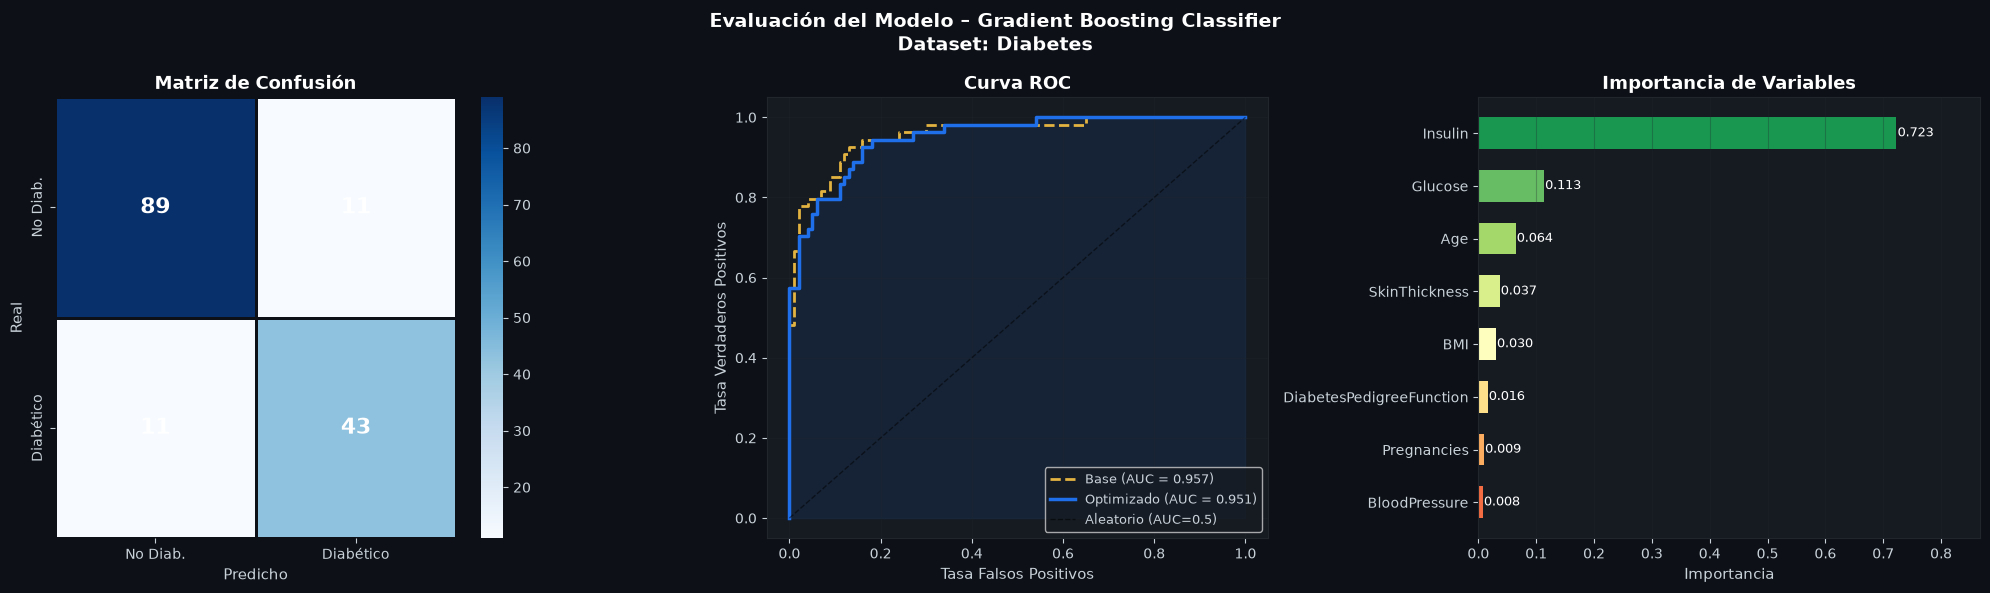

Gráfica guardada como SA2_clasificacion_evaluacion.png


In [16]:
# Recalcular predicciones del modelo base por si la celda no se ejecutó
gb_base = GradientBoostingClassifier(random_state=42)
gb_base.fit(X_train, y_train)
y_pred_base = gb_base.predict(X_test)
y_prob_base = gb_base.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Evaluación del Modelo – Gradient Boosting Classifier\nDataset: Diabetes', 
             fontsize=14, fontweight='bold', color='white')

# --- 1. Matriz de confusión ---
ax1 = axes[0]
cm = confusion_matrix(y_test, y_pred_opt)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['No Diab.', 'Diabético'],
            yticklabels=['No Diab.', 'Diabético'],
            linewidths=2, linecolor='#0d1117',
            annot_kws={'size': 16, 'fontweight': 'bold', 'color': 'white'})
ax1.set_title('Matriz de Confusión', fontsize=13, fontweight='bold', color='white')
ax1.set_ylabel('Real', fontsize=11)
ax1.set_xlabel('Predicho', fontsize=11)

# --- 2. Curva ROC ---
ax2 = axes[1]
fpr_b, tpr_b, _ = roc_curve(y_test, y_prob_base)
fpr_o, tpr_o, _ = roc_curve(y_test, y_prob_opt)
ax2.plot(fpr_b, tpr_b, color=C_WARN, linewidth=2, linestyle='--',
         label=f'Base (AUC = {roc_auc_score(y_test, y_prob_base):.3f})')
ax2.plot(fpr_o, tpr_o, color=C_ACC, linewidth=2.5,
         label=f'Optimizado (AUC = {auc:.3f})')
ax2.plot([0,1],[0,1], 'k--', alpha=0.5, linewidth=1, label='Aleatorio (AUC=0.5)')
ax2.fill_between(fpr_o, tpr_o, alpha=0.1, color=C_ACC)
ax2.set_xlabel('Tasa Falsos Positivos', fontsize=11)
ax2.set_ylabel('Tasa Verdaderos Positivos', fontsize=11)
ax2.set_title(f'Curva ROC', fontsize=13, fontweight='bold', color='white')
ax2.legend(fontsize=9, loc='lower right')
ax2.grid(True, alpha=0.3)

# --- 3. Importancia de variables ---
ax3 = axes[2]
feat_imp = pd.DataFrame({'Feature': X.columns, 'Importance': gb_opt.feature_importances_})
feat_imp = feat_imp.sort_values('Importance')
colors_bar = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(feat_imp)))
bars = ax3.barh(feat_imp['Feature'], feat_imp['Importance'], color=colors_bar, height=0.6)
for bar, val in zip(bars, feat_imp['Importance']):
    ax3.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9, color='white')
ax3.set_xlabel('Importancia', fontsize=11)
ax3.set_title('Importancia de Variables', fontsize=13, fontweight='bold', color='white')
ax3.grid(True, alpha=0.3, axis='x')
ax3.set_xlim(0, feat_imp['Importance'].max() * 1.2)

plt.tight_layout()
plt.savefig('SA2_clasificacion_evaluacion.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Gráfica guardada como SA2_clasificacion_evaluacion.png')

## 9. Paso 8 – Gráfica de distribución de probabilidades predichas

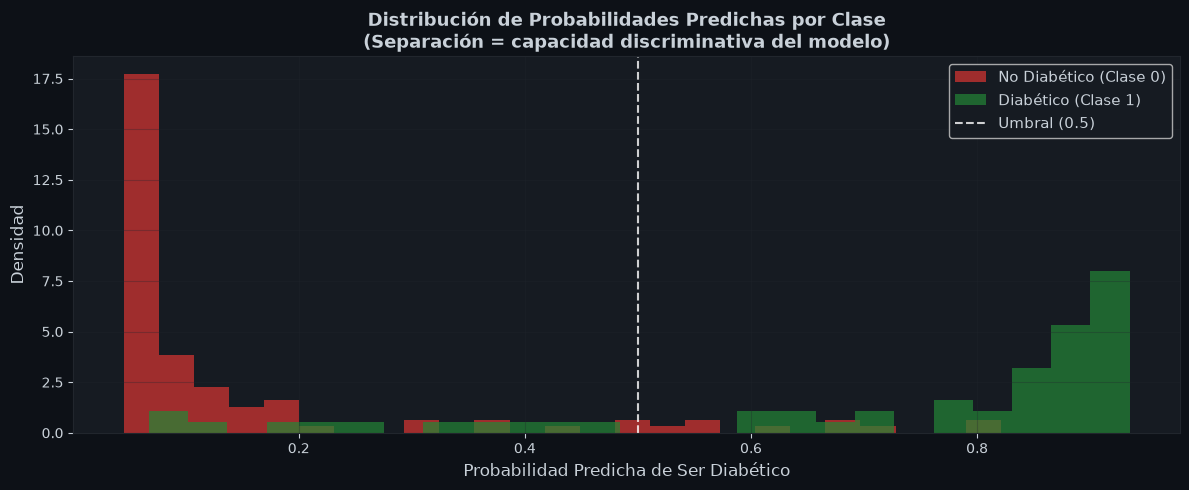

Gráfica guardada como SA2_distribucion_prob.png


In [17]:
fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('#0d1117')

ax.hist(y_prob_opt[y_test == 0], bins=25, alpha=0.7, color=C_NEG,
        label='No Diabético (Clase 0)', edgecolor='none', density=True)
ax.hist(y_prob_opt[y_test == 1], bins=25, alpha=0.7, color=C_POS,
        label='Diabético (Clase 1)', edgecolor='none', density=True)
ax.axvline(x=0.5, color='white', linestyle='--', linewidth=1.5, label='Umbral (0.5)', alpha=0.8)

ax.set_xlabel('Probabilidad Predicha de Ser Diabético', fontsize=12)
ax.set_ylabel('Densidad', fontsize=12)
ax.set_title('Distribución de Probabilidades Predichas por Clase\n(Separación = capacidad discriminativa del modelo)', 
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('SA2_distribucion_prob.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Gráfica guardada como SA2_distribucion_prob.png')

## 10. Paso 9 – Guardar el modelo

In [18]:
joblib.dump(gb_opt, 'SA2_modelo_clasificacion_gb.pkl')
joblib.dump(scaler, 'SA2_scaler.pkl')
print('✓ Modelo guardado: SA2_modelo_clasificacion_gb.pkl')
print('✓ Scaler guardado: SA2_scaler.pkl')

print('\n=== RESUMEN FINAL ===')
print(f'Algoritmo:         Gradient Boosting Classifier')
print(f'Mejores params:    {grid_search.best_params_}')
print(f'Accuracy:          {acc:.4f}')
print(f'F1 Score:          {f1:.4f}')
print(f'AUC-ROC:           {auc:.4f}')
print(f'Precision:         {prec:.4f}')
print(f'Recall:            {rec:.4f}')

✓ Modelo guardado: SA2_modelo_clasificacion_gb.pkl
✓ Scaler guardado: SA2_scaler.pkl

=== RESUMEN FINAL ===
Algoritmo:         Gradient Boosting Classifier
Mejores params:    {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 50, 'subsample': 0.8}
Accuracy:          0.8571
F1 Score:          0.7963
AUC-ROC:           0.9507
Precision:         0.7963
Recall:            0.7963


In [19]:
print(f'Accuracy base:  {accuracy_score(y_test, y_pred_base):.4f}')
print(f'F1 Score base:  {f1_score(y_test, y_pred_base):.4f}')
print(f'AUC-ROC base:   {roc_auc_score(y_test, y_prob_base):.4f}')
print(f'Precision base: {precision_score(y_test, y_pred_base):.4f}')
print(f'Recall base:    {recall_score(y_test, y_pred_base):.4f}')


Accuracy base:  0.8831
F1 Score base:  0.8333
AUC-ROC base:   0.9569
Precision base: 0.8333
Recall base:    0.8333
